In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm
import seaborn as sns
import numpy as np

In [3]:
#load data
daily_weather = pd.read_csv("../../data/01-interim/Weather/CLEANED_CentralPark_Weather2023.csv")
daily_ridership = pd.read_csv("../../data/01-interim/MTA_subway/MTA_Subway_Daily_Manhattan_Totals.csv")
daily_rides = pd.read_csv("../../data/02-processed/daily_total_ridership.csv")

In [4]:
daily_weather = daily_weather.drop(['Station','Name','Latitude','Longitude','Snow','Snow?', 'Precipitation', 'Rain?'], axis = 1)

In [5]:
#idk if this is correct, needs a central assumption
#model = sm.OLS(daily_ridership['ridership'], daily_weather['Avg_Temp']).fit()
#model.summary()

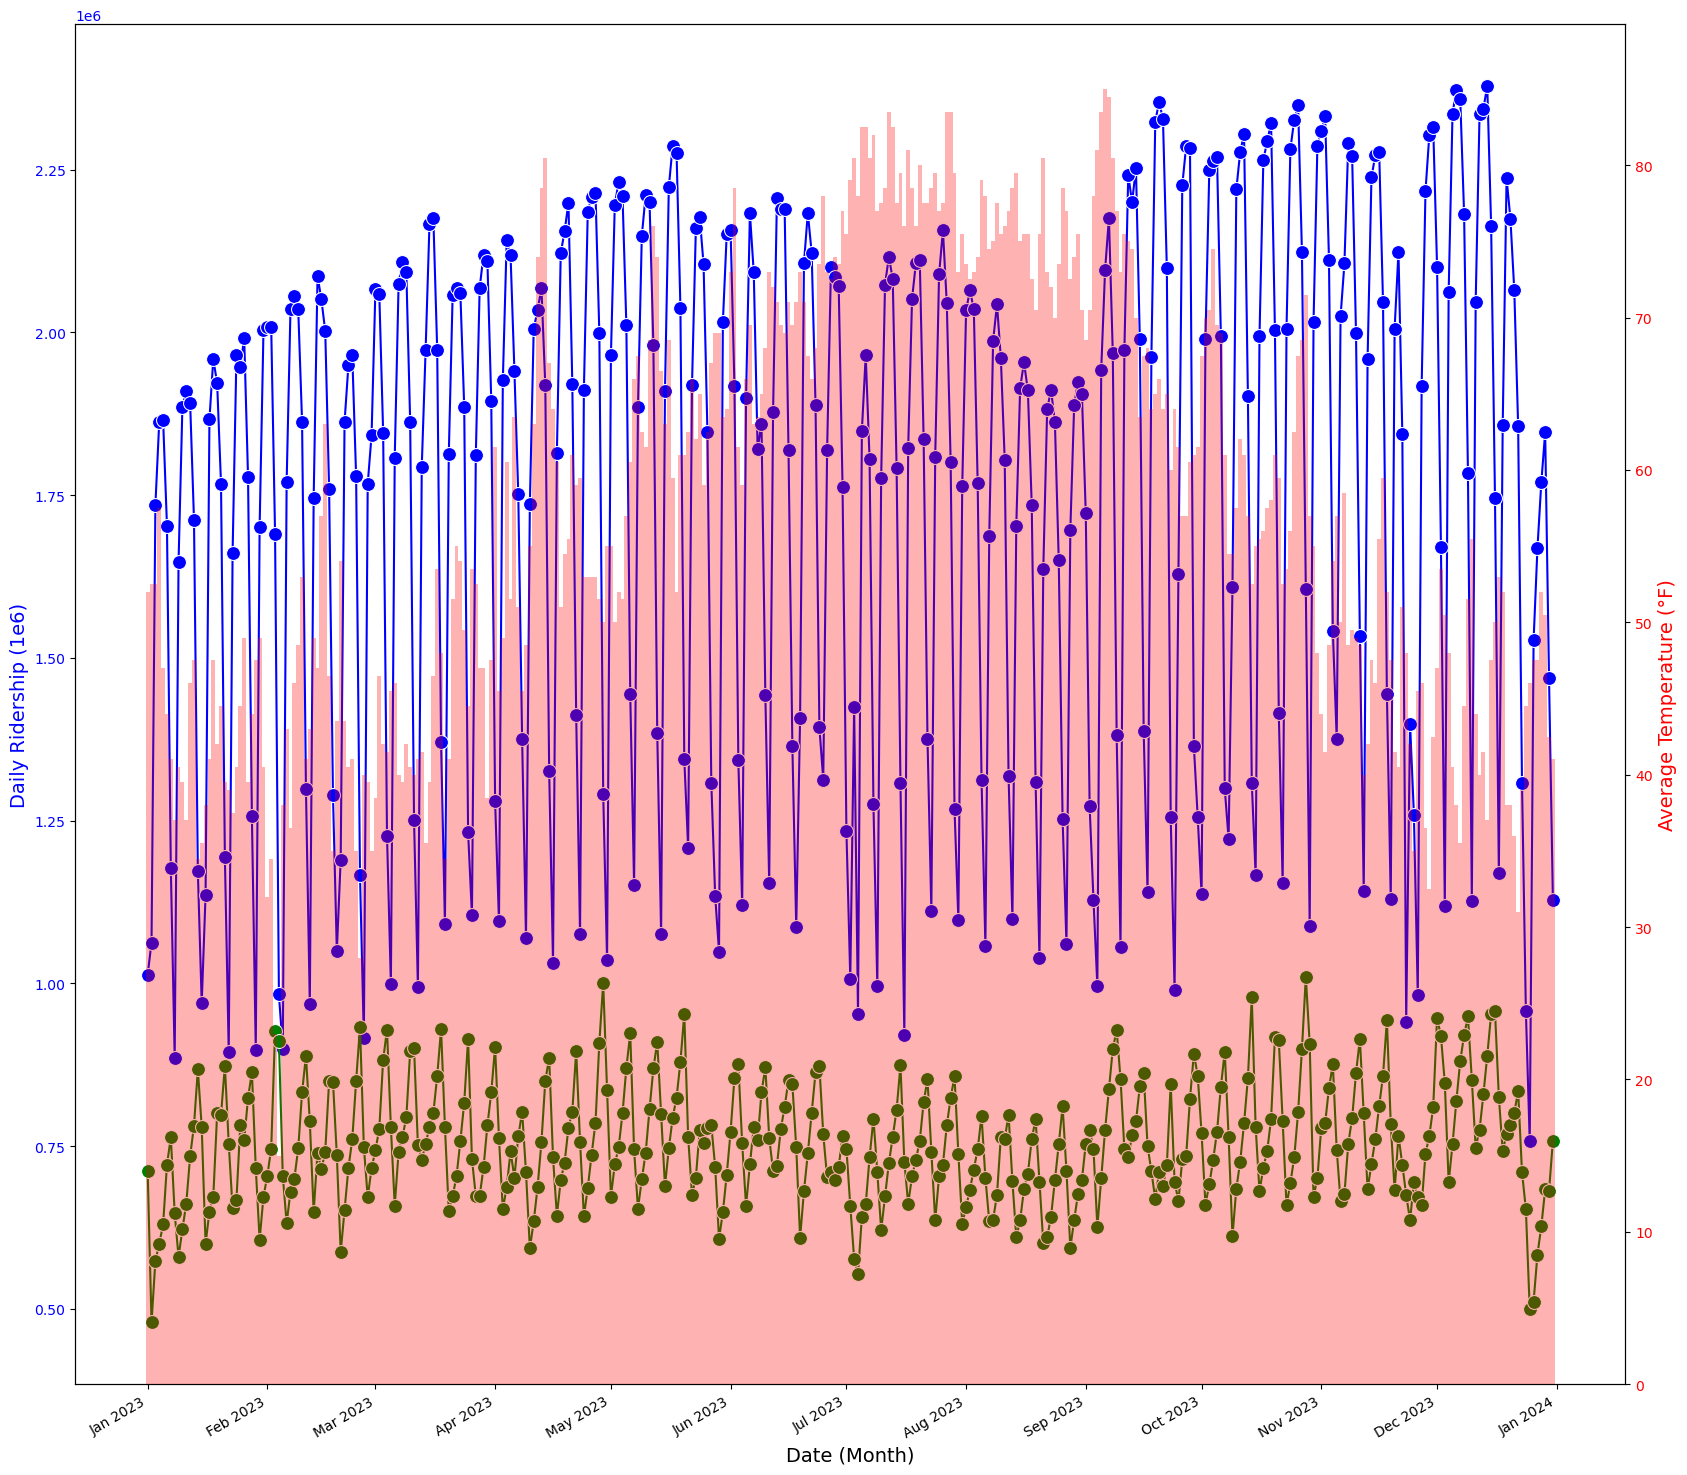

In [7]:
#ik this is messy af but this is my kid and i love her despite her deformities
daily_weather['Date'] = pd.to_datetime(daily_weather['Date'])
daily_ridership['date'] = pd.to_datetime(daily_ridership['date'])
daily_rides['date'] = pd.to_datetime(daily_rides['date'])

fig, ax = plt.subplots()
fig.set_figheight(20)
fig.set_figwidth(20)
sns.lineplot(x = 'date', y = 'ridership', data = daily_ridership, ax = ax, marker = 'o', markersize = 10, color = 'blue')
sns.lineplot(x = 'date', y = 'total_daily_trips', data = daily_rides, ax = ax, marker = 'o', markersize = 10, color = 'green')

ax2 = ax.twinx()
ax2.bar(daily_weather['Date'], daily_weather['Avg_Temp'],color = 'red', alpha = 0.3, width = 1.0)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

ax.set_xlabel('Date (Month)', fontsize = 14)
ax.set_ylabel('Daily Ridership (1e6)', color='blue', fontsize=14)
ax.tick_params(axis='y', labelcolor='blue')
ax2.set_ylabel('Average Temperature (°F)', color = 'red', fontsize = 14)
ax2.tick_params(axis='y', labelcolor='red')
fig.autofmt_xdate()

#errorbar graveyard
#y_err = np.array(daily_weather[['Min_Temp', 'Max_Temp']])
#ax.errorbar(x = daily_weather['Date'], y = daily_weather['Avg_Temp'], yerr = y_err, fmt = 'none')

#didnt hv time to figure out legend :p

/tmp/ipykernel_14032/3456544793.py:8: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  merged = merged[~merged['date'].isin(outliers)]


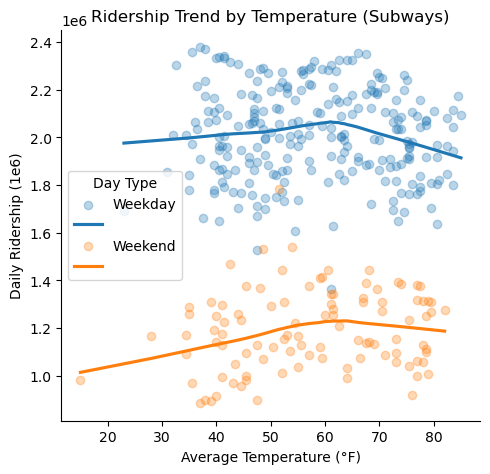

In [8]:
#ridership and average temperature threshold (visual)
daily_ridership['is_weekend'] = daily_ridership['date'].dt.dayofweek > 4
merged = daily_ridership.merge(daily_weather, left_on='date', right_on='Date')

#remove outliers
outliers = ['2023-01-02','2023-01-16','2023-02-20','2023-05-29','2023-06-19','2023-07-03','2023-07-04',
            '2023-09-04','2023-10-28','2023-11-23','2023-11-24','2023-12-02','2023-12-16','2023-12-25']
merged = merged[~merged['date'].isin(outliers)]


sns.lmplot(x='Avg_Temp', y='ridership', data=merged, hue='is_weekend', lowess = True, scatter_kws={'alpha':0.3}, legend = False)
plt.legend(title = 'Day Type', labels = ['Weekday',' ','Weekend',' '], loc = 'center left')
plt.title('Ridership Trend by Temperature (Subways)')
plt.xlabel('Average Temperature (°F)')
plt.ylabel('Daily Ridership (1e6)')
plt.subplots_adjust(right=0.8)
plt.tight_layout()


/tmp/ipykernel_14032/4044738942.py:10: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  merged2 = merged2[~merged2['date'].isin(outliers)]


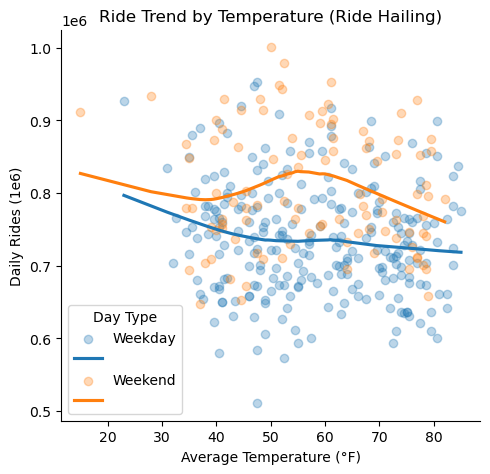

In [9]:
#ride hailing and average temperature threshold (visual)
daily_rides['date'] = pd.to_datetime(daily_rides['date'])

daily_rides['is_weekend'] = daily_rides['date'].dt.dayofweek > 4
merged2 = daily_rides.merge(daily_weather, left_on='date', right_on='Date')

#remove outliers
outliers = ['2023-01-02','2023-01-16','2023-02-20','2023-05-29','2023-06-19','2023-07-03','2023-07-04',
            '2023-09-04','2023-10-28','2023-11-23','2023-11-24','2023-12-02','2023-12-16','2023-12-25']
merged2 = merged2[~merged2['date'].isin(outliers)]

sns.lmplot(x='Avg_Temp', y='total_daily_trips', data=merged2, hue='is_weekend', lowess = True, scatter_kws={'alpha':0.3}, legend = False)
plt.legend(title = 'Day Type', labels = ['Weekday',' ','Weekend',' '], loc = 'lower left')
plt.title('Ride Trend by Temperature (Ride Hailing)')
plt.xlabel('Average Temperature (°F)')
plt.ylabel('Daily Rides (1e6)')
plt.subplots_adjust(right=0.8)
plt.tight_layout()

In [10]:
from statsmodels.nonparametric.smoothers_lowess import lowess
#subway peaks
#define weekday/weekends
subway_weekdays = merged[~merged['is_weekend']].copy()
subway_weekends = merged[ merged['is_weekend']].copy()


#fit lowess
lowess_weekday = lowess(subway_weekdays['ridership'], subway_weekdays['Avg_Temp'])
lowess_weekend = lowess(subway_weekends['ridership'], subway_weekends['Avg_Temp'])

# Find peaks
x_wd, y_wd = lowess_weekday.T
x_we, y_we = lowess_weekend.T

peak_temp_weekday = x_wd[np.argmax(y_wd)]
peak_ridership_wd = y_wd.max()

peak_temp_weekend = x_we[np.argmax(y_we)]
peak_ridership_we = y_we.max()

print(f"Weekday subway ridership peak at ~ {peak_temp_weekday:4.1f} °F, {peak_ridership_wd/1e6:5.2f} million")
print(f"Weekend subway ridership peak at ~ {peak_temp_weekend:4.1f} °F,  {peak_ridership_we/1e6:5.2f} million")

Weekday subway ridership peak at ~ 61.0 °F,  2.07 million
Weekend subway ridership peak at ~ 64.0 °F,   1.23 million


In [11]:
#ride hailing peaks
#define weekday/weekends
ridership_weekdays = merged2[~merged2['is_weekend']].copy()
ridership_weekends  = merged2[ merged2['is_weekend']].copy()

#filter ends
temp_min, temp_max = 45, 90

ridership_weekdays_filtered = ridership_weekdays[(ridership_weekdays['Avg_Temp'] >= temp_min) &(ridership_weekdays['Avg_Temp'] <= temp_max)].copy()
ridership_weekends_filtered = ridership_weekends[(ridership_weekends['Avg_Temp'] >= temp_min) &(ridership_weekends['Avg_Temp'] <= temp_max)].copy()

#fit lowess
lowess_weekday2 = lowess(ridership_weekdays_filtered['total_daily_trips'], ridership_weekdays_filtered['Avg_Temp'])
lowess_weekend2 = lowess(ridership_weekends_filtered['total_daily_trips'], ridership_weekends_filtered['Avg_Temp'])

# Find peaks
x_wd2, y_wd2 = lowess_weekday2.T
x_we2, y_we2 = lowess_weekend2.T

peak_temp_weekday2 = x_wd2[np.argmax(y_wd2)]
peak_ridership_wd2 = y_wd2.max()

peak_temp_weekend2 = x_we2[np.argmax(y_we2)]
peak_ridership_we2= y_we2.max()

print(f"Weekday ride share rides peak at ~ {peak_temp_weekday2:4.1f} °F,  {peak_ridership_wd2/1e6:5.2f} million")
print(f"Weekend ride share rides peak at ~ {peak_temp_weekend2:4.1f} °F,  {peak_ridership_we2/1e6:5.2f} million")

Weekday ride share rides peak at ~ 63.0 °F,   0.74 million
Weekend ride share rides peak at ~ 57.0 °F,   0.84 million


In [ ]:
#OLD STUFF
#ridership and average temperature threshold (mathematical)
#def find_peak(data):
#    z = np.polyfit(data['Avg_Temp'], data['ridership'], 2)
#    p = np.poly1d(z)
    
#    peak_temp = -z[1] / (2 * z[0])
#    return peak_temp

#weekday_peak = find_peak(merged[merged['is_weekend'] == False])
#weekend_peak = find_peak(merged[merged['is_weekend'] == True])

#print(f"Weekday Ridership peaks at: {weekday_peak:.1f}°")
#print(f"Weekend Ridership peaks at: {weekend_peak:.1f}°")
#ride hailing and average temperature threshold (mathematical)
#def find_peak2(data):
#    z = np.polyfit(data['Avg_Temp'], data['total_daily_trips'], 2)
#    p = np.poly1d(z)
#    
#    peak_temp = -z[1] / (2 * z[0])
#    return peak_temp


#weekday_peak2 = find_peak2(merged2[merged2['is_weekend'] == False])
#weekend_peak2 = find_peak2(merged2[merged2['is_weekend'] == True])

#print(f"Weekday Rides peak at: {weekday_peak2:.1f}°")
#print(f"Weekend Rides peak at: {weekend_peak2:.1f}°")